# Portfolio Optimization with a Genetic Algorithm

Notebook port of `genetic_algorithm.py`.

Requires `stock_data_with_sharpe_ratio.pkl` (produce it by running `data.py`).

## Configuration

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

CONFIG = {
    "data_path": "stock_data_with_sharpe_ratio.pkl",
    "risk_free_rate": 0.04,       # annual risk-free rate (e.g. ~4% Canadian T-bill)
    "population_size": 100,
    "num_generations": 200,
    "mutation_rate": 0.1,
    "tournament_size": 5,
    "elite_count": 5,
    "trading_days_per_year": 252,
}

## Data Loading

In [79]:
def load_data(path):
    raw = pd.read_pickle(path)
    closes = pd.DataFrame({ticker: df["Close"] for ticker, df in raw.items()})

    closes.index = pd.to_datetime(closes.index, utc=True)
    return closes.sort_index().dropna()


def compute_returns(closes):
    return closes.pct_change().dropna()


closes = load_data(CONFIG["data_path"])
# exclude = [
#     "IBM", "MRK", "GS", "PG", "AMGN", "HD", "JPM", "NKE",
#     "MMM", "MCD", "HON", "TRV", "DIS", "AXP", "MSFT",
#     "V", "SHW", "CRM", "WMT", "AAPL", "NVDA"
# ]

# closes = closes.drop(columns=exclude)
tickers = list(closes.columns)
n_stocks = len(tickers)
daily_returns = compute_returns(closes)
mean_returns = daily_returns.mean().values
cov_matrix = daily_returns.cov().values

print(f"Loaded {n_stocks} stocks, {len(daily_returns)} trading days.")

Loaded 28 stocks, 109 trading days.


## Fitness: Portfolio Sharpe Ratio

In [80]:
def sharpe_ratio(weights, mean_returns, cov_matrix, risk_free_rate, trading_days):
    w = np.array(weights) / 100.0
    port_return = np.dot(w, mean_returns) * trading_days
    port_vol = np.sqrt(np.dot(w.T, np.dot(cov_matrix * trading_days, w)))
    if port_vol == 0:
        return -np.inf
    return (port_return - risk_free_rate) / port_vol

## Chromosome Helpers

Each individual is an integer allocation summing to 100.

In [81]:
def normalize_to_100(weights):
    """Scale a list of non-negative numbers to integer weights summing to 100."""
    total = sum(weights)
    if total == 0:
        return equal_weight_chromosome(len(weights))
    scaled = [int(w * 100 / total) for w in weights]
    remainder = 100 - sum(scaled)
    # Distribute remainder to indices with highest fractional parts
    fractions = sorted(
        range(len(weights)), key=lambda i: (weights[i] * 100 / total) % 1, reverse=True
    )
    for i in range(remainder):
        scaled[fractions[i]] += 1
    return scaled


def equal_weight_chromosome(n):
    """First parent: divide money evenly across all stocks."""
    base = 100 // n
    weights = [base] * n
    remainder = 100 - sum(weights)
    for i in range(remainder):
        weights[i] += 1
    return weights


def random_chromosome(n):
    """Random valid integer allocation summing to 100."""
    cuts = sorted(random.sample(range(1, 100), n - 1))
    cuts = [0] + cuts + [100]
    return [cuts[i + 1] - cuts[i] for i in range(n)]


def init_population(n_stocks, pop_size):
    population = [equal_weight_chromosome(n_stocks)]  # required first parent
    while len(population) < pop_size:
        population.append(random_chromosome(n_stocks))
    return population

## Selection, Crossover, Mutation

In [82]:
def tournament_select(population, fitness_scores, tournament_size):
    candidates = random.sample(list(enumerate(population)), tournament_size)
    winner = max(candidates, key=lambda x: fitness_scores[x[0]])
    return winner[1]


def crossover(parent1, parent2):
    n = len(parent1)
    point = random.randint(1, n - 1)
    child = parent1[:point] + parent2[point:]
    return normalize_to_100(child)


def mutate(weights, mutation_rate):
    weights = weights[:]
    n = len(weights)
    for _ in range(n):
        if random.random() < mutation_rate:
            donors = [i for i in range(n) if weights[i] > 1]
            if len(donors) < 1:
                continue
            i = random.choice(donors)
            j = random.choice([k for k in range(n) if k != i])
            transfer = random.randint(1, weights[i] - 1)
            weights[i] -= transfer
            weights[j] += transfer
    return weights

## Genetic Algorithm Main Loop

In [83]:
def run_ga(mean_returns, cov_matrix, config):
    n_stocks = len(mean_returns)
    pop_size = config["population_size"]
    n_gen = config["num_generations"]
    mut_rate = config["mutation_rate"]
    tourn_size = config["tournament_size"]
    elite_count = config["elite_count"]
    rf = config["risk_free_rate"]
    td = config["trading_days_per_year"]

    population = init_population(n_stocks, pop_size)
    best_per_gen = []

    for gen in range(n_gen):
        fitness = [
            sharpe_ratio(ind, mean_returns, cov_matrix, rf, td) for ind in population
        ]
        best_per_gen.append(max(fitness))

        if (gen + 1) % 50 == 0:
            print(f"  Generation {gen + 1}/{n_gen} — Best Sharpe: {max(fitness):.4f}")

        ranked = sorted(zip(fitness, population), key=lambda x: x[0], reverse=True)
        next_gen = [ind for _, ind in ranked[:elite_count]]

        while len(next_gen) < pop_size:
            p1 = tournament_select(population, fitness, tourn_size)
            p2 = tournament_select(population, fitness, tourn_size)
            child = crossover(p1, p2)
            child = mutate(child, mut_rate)
            next_gen.append(child)

        population = next_gen

    fitness = [sharpe_ratio(ind, mean_returns, cov_matrix, rf, td) for ind in population]
    best_idx = int(np.argmax(fitness))
    return population[best_idx], fitness[best_idx], best_per_gen

## Baselines

In [84]:
def evaluate_baselines(n_stocks, mean_returns, cov_matrix, config):
    rf = config["risk_free_rate"]
    td = config["trading_days_per_year"]

    equal = equal_weight_chromosome(n_stocks)
    rand = random_chromosome(n_stocks)

    return {
        "Equal Weight": (equal, sharpe_ratio(equal, mean_returns, cov_matrix, rf, td)),
        "Random":       (rand,  sharpe_ratio(rand,  mean_returns, cov_matrix, rf, td)),
    }

## Run

In [85]:
print(f"Running GA: {CONFIG['num_generations']} generations, "
      f"population {CONFIG['population_size']}...\n")

best_weights, best_sharpe, convergence = run_ga(mean_returns, cov_matrix, CONFIG)
baselines = evaluate_baselines(n_stocks, mean_returns, cov_matrix, CONFIG)

results = {
    "GA Portfolio":     {"weights": best_weights, "sharpe": best_sharpe},
    "Equal Weight":     {"weights": baselines["Equal Weight"][0], "sharpe": baselines["Equal Weight"][1]},
    "Random Portfolio": {"weights": baselines["Random"][0], "sharpe": baselines["Random"][1]},
}

print("\n── Portfolio Comparison ──────────────────────────")
for name, res in results.items():
    print(f"  {name:20s}: Sharpe = {res['sharpe']:.4f}")

print("\n── GA Best Allocation ────────────────────────────")
for ticker, w in sorted(zip(tickers, best_weights), key=lambda x: x[1], reverse=True):
    if w > 0:
        print(f"  {ticker}: {w}%")
print(f"  Total: {sum(best_weights)}%")

Running GA: 200 generations, population 100...

  Generation 50/200 — Best Sharpe: 3.9608
  Generation 100/200 — Best Sharpe: 3.9608
  Generation 150/200 — Best Sharpe: 3.9608
  Generation 200/200 — Best Sharpe: 3.9612

── Portfolio Comparison ──────────────────────────
  GA Portfolio        : Sharpe = 3.9612
  Equal Weight        : Sharpe = 0.6165
  Random Portfolio    : Sharpe = 0.6842

── GA Best Allocation ────────────────────────────
  KO: 26%
  CVX: 15%
  CSCO: 15%
  JNJ: 9%
  UNH: 6%
  CAT: 5%
  VZ: 3%
  IBM: 1%
  MRK: 1%
  GS: 1%
  PG: 1%
  AMGN: 1%
  HD: 1%
  JPM: 1%
  NKE: 1%
  MMM: 1%
  MCD: 1%
  HON: 1%
  TRV: 1%
  DIS: 1%
  AXP: 1%
  MSFT: 1%
  V: 1%
  SHW: 1%
  CRM: 1%
  WMT: 1%
  AAPL: 1%
  NVDA: 1%
  Total: 100%


## Plots

Same three figures as the script, shown inline instead of saved to PNG.

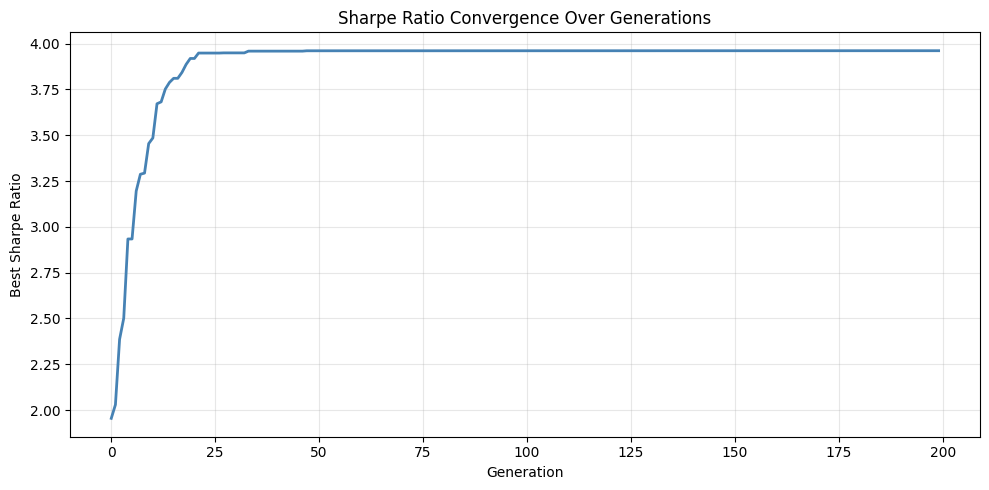

In [86]:
plt.figure(figsize=(10, 5))
plt.plot(convergence, color="steelblue", linewidth=2)
plt.title("Sharpe Ratio Convergence Over Generations")
plt.xlabel("Generation")
plt.ylabel("Best Sharpe Ratio")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

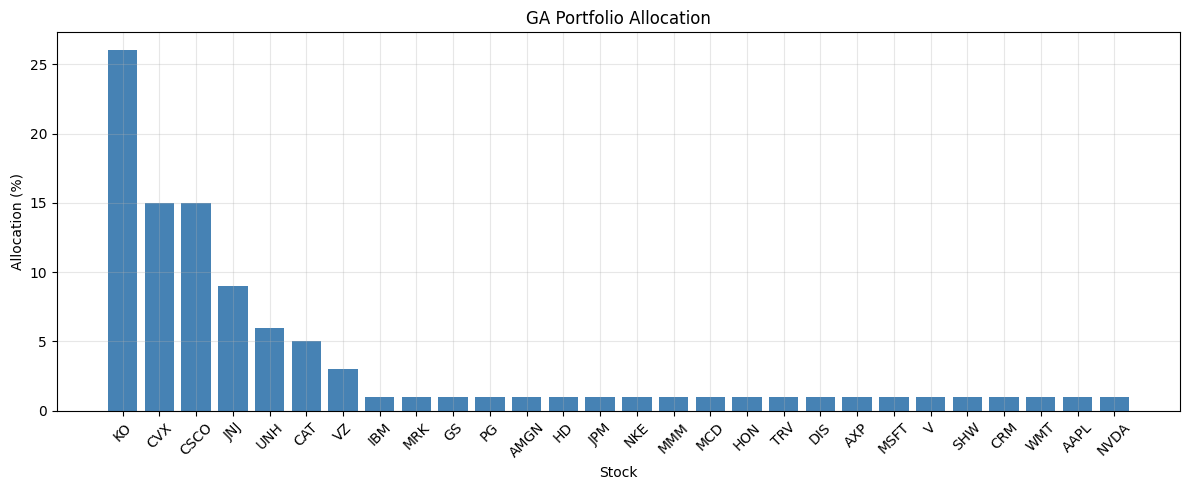

In [87]:
pairs = [(t, w) for t, w in zip(tickers, best_weights) if w > 0]
pairs.sort(key=lambda x: x[1], reverse=True)
labels, vals = zip(*pairs)

plt.figure(figsize=(12, 5))
plt.bar(labels, vals, color="steelblue")
plt.title("GA Portfolio Allocation")
plt.xlabel("Stock")
plt.ylabel("Allocation (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

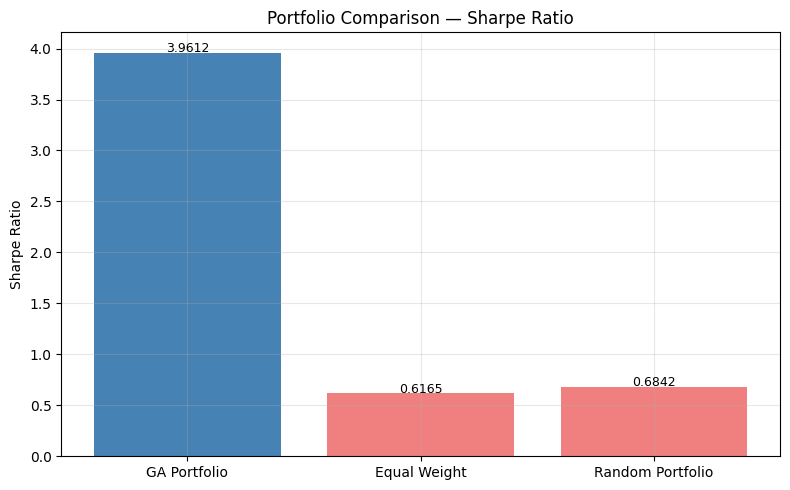

In [88]:
names = list(results.keys())
sharpes = [results[n]["sharpe"] for n in names]
colors = ["steelblue" if n == "GA Portfolio" else "lightcoral" for n in names]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, sharpes, color=colors)
plt.title("Portfolio Comparison — Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, sharpes):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center",
        fontsize=9,
    )
plt.tight_layout()
plt.show()